<a href="https://colab.research.google.com/github/essanchristian-maker/DI-Bootcamp/blob/master/Week5_Day2_Exercises_XP_Ninja_student_SOTA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Exercises XP Ninja: Guided Student Notebook

This guided notebook follows the **exercises on the platform**. Cells marked **PREFILLED** are for execution only. Cells marked **To-Do** require your action. When a written answer is required, the **To-Do** appears inside a markdown cell. When code is required, the **To-Do** appears inside a code cell as comments.

Learning points are included only when a concept is important for intuition or transfer to other AI topics.


## Reference from the exercises

**What you will learn**  
- Implement state-of-the-art techniques to solve complex machine learning problems.
- Understand and apply advanced optimization methods for deep learning.
- Build and fine tune large scale models for real world applications.
- Explore cutting edge research areas like generative models and reinforcement learning.
- Develop strategies to handle imbalanced datasets and improve model robustness.

**What you will create**  
A deep learning model optimized using learning rate scheduling and gradient clipping. A generative model to create synthetic data. A reinforcement learning agent for a specific task. A robust model trained on an imbalanced dataset using SMOTE or focal loss. A comparison of performance before and after advanced strategies.


## Exercise 1: Advanced Optimization Techniques for Deep Learning

**As stated in the exercises**  
Objective. Improve model training stability and convergence using advanced optimization techniques.  
Instructions. Choose a deep learning model such as a CNN or RNN and a dataset such as CIFAR 10 or IMDB. Implement learning rate scheduling such as cosine annealing or step decay during training. Apply gradient clipping to prevent exploding gradients. Compare training stability and convergence with and without these techniques. Write a short analysis of how these techniques improve training.

**Guidance**  
Use CIFAR 10 with a small CNN for quick runs. Compare baseline vs scheduled learning rate and gradient clipping. Track training and validation curves.


**Learning point**  
Learning rate schedules reduce the step size as training progresses which helps convergence near minima. Cosine schedules can give sharper early progress. Gradient clipping caps update magnitude to prevent unstable jumps, especially in RNNs or deep CNNs.


In [5]:
# PREFILLED: just execute
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models

print("TensorFlow:", tf.__version__)

# CIFAR-10 data
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical

(x_tr, y_tr), (x_te, y_te) = cifar10.load_data()
x_tr = x_tr.astype("float32")/255.0
x_te = x_te.astype("float32")/255.0
y_tr_oh = to_categorical(y_tr, 10)
y_te_oh = to_categorical(y_te, 10)

x_tr.shape, y_tr_oh.shape, x_te.shape, y_te_oh.shape

TensorFlow: 2.20.0
170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 2036s 12us/step


((50000, 32, 32, 3), (50000, 10), (10000, 32, 32, 3), (10000, 10))

In [6]:
# PREFILLED: just execute
def build_cnn(clipnorm=None, clipvalue=None, lr=1e-3):
    inputs = layers.Input(shape=(32,32,3))
    x = layers.Conv2D(32, 3, padding="same", activation="relu")(inputs)
    x = layers.MaxPooling2D()(x)
    x = layers.Conv2D(64, 3, padding="same", activation="relu")(x)
    x = layers.MaxPooling2D()(x)
    x = layers.Flatten()(x)
    x = layers.Dense(128, activation="relu")(x)
    outputs = layers.Dense(10, activation="softmax")(x)
    model = models.Model(inputs, outputs)
    opt = tf.keras.optimizers.Adam(learning_rate=lr, clipnorm=clipnorm, clipvalue=clipvalue)
    model.compile(optimizer=opt, loss="categorical_crossentropy", metrics=["accuracy"])
    return model

baseline = build_cnn()
hist_base = baseline.fit(x_tr, y_tr_oh, validation_split=0.1, epochs=3, batch_size=128, verbose=2)

Epoch 1/3
352/352 - 9s - 27ms/step - accuracy: 0.4498 - loss: 1.5454 - val_accuracy: 0.5078 - val_loss: 1.3767
Epoch 2/3
352/352 - 2s - 6ms/step - accuracy: 0.5896 - loss: 1.1704 - val_accuracy: 0.6220 - val_loss: 1.0959
Epoch 3/3
352/352 - 2s - 6ms/step - accuracy: 0.6427 - loss: 1.0209 - val_accuracy: 0.6602 - val_loss: 0.9975


In [7]:
# To-Do: implement a learning rate schedule and train with gradient clipping

# Option 1: use tf.keras.optimizers.schedules.CosineDecay with an initial lr
initial_learning_rate = 1e-3
decay_steps = 3 * (int(x_tr.shape[0] * 0.9 / 128))
lr_schedule = tf.keras.optimizers.schedules.CosineDecay(
    initial_learning_rate=initial_learning_rate,
    decay_steps=decay_steps
)
model_sched = build_cnn(lr=lr_schedule)
hist_sched = model_sched.fit(x_tr, y_tr_oh, validation_split=0.1, epochs=3, batch_size=128, verbose=2)

# Option 2: step decay via a callback (not implemented, but for context)
# def step_decay(epoch, lr):
#     return lr
# cb = tf.keras.callbacks.LearningRateScheduler(step_decay)

# Train a clipped model
model_clip = build_cnn(clipnorm=1.0, lr=1e-3)
hist_clip = model_clip.fit(x_tr, y_tr_oh, validation_split=0.1, epochs=3, batch_size=128, verbose=2)

# Compare histories: plot loss and accuracy for baseline vs clipped or scheduled (to be done in the next step)

Epoch 1/3
352/352 - 7s - 20ms/step - accuracy: 0.4484 - loss: 1.5350 - val_accuracy: 0.5424 - val_loss: 1.2986
Epoch 2/3
352/352 - 6s - 18ms/step - accuracy: 0.5820 - loss: 1.1869 - val_accuracy: 0.6138 - val_loss: 1.1201
Epoch 3/3
352/352 - 2s - 7ms/step - accuracy: 0.6253 - loss: 1.0759 - val_accuracy: 0.6326 - val_loss: 1.0829
Epoch 1/3
352/352 - 7s - 20ms/step - accuracy: 0.4422 - loss: 1.5497 - val_accuracy: 0.5446 - val_loss: 1.3187
Epoch 2/3
352/352 - 2s - 6ms/step - accuracy: 0.5762 - loss: 1.1996 - val_accuracy: 0.6124 - val_loss: 1.1017
Epoch 3/3
352/352 - 2s - 7ms/step - accuracy: 0.6298 - loss: 1.0548 - val_accuracy: 0.6512 - val_loss: 0.9969


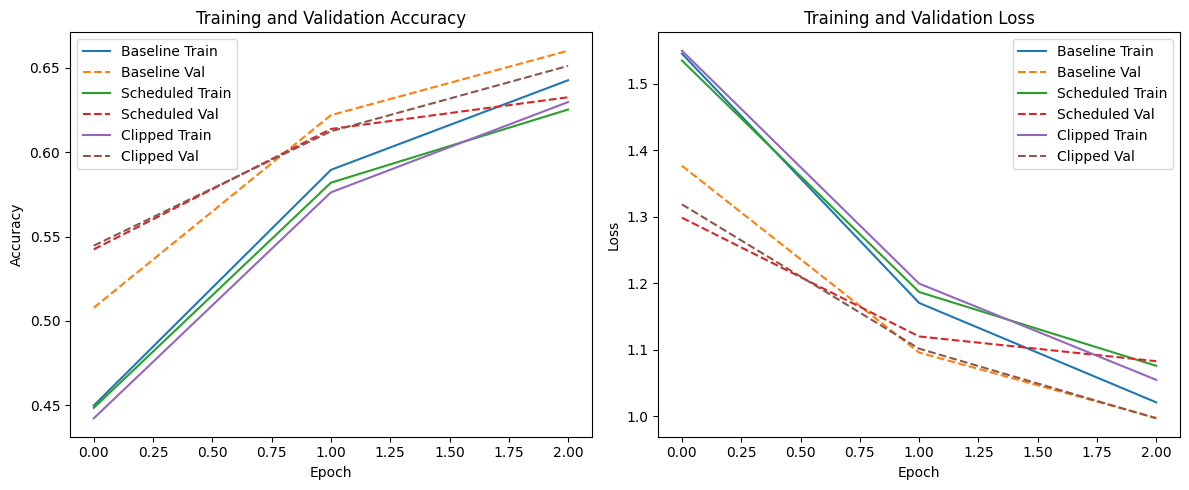

In [8]:
import matplotlib.pyplot as plt

# Figure 1: Accuracy comparison
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(hist_base.history['accuracy'], label='Baseline Train')
plt.plot(hist_base.history['val_accuracy'], label='Baseline Val', linestyle='--')
plt.plot(hist_sched.history['accuracy'], label='Scheduled Train')
plt.plot(hist_sched.history['val_accuracy'], label='Scheduled Val', linestyle='--')
plt.plot(hist_clip.history['accuracy'], label='Clipped Train')
plt.plot(hist_clip.history['val_accuracy'], label='Clipped Val', linestyle='--')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Figure 2: Loss comparison
plt.subplot(1, 2, 2)
plt.plot(hist_base.history['loss'], label='Baseline Train')
plt.plot(hist_base.history['val_loss'], label='Baseline Val', linestyle='--')
plt.plot(hist_sched.history['loss'], label='Scheduled Train')
plt.plot(hist_sched.history['val_loss'], label='Scheduled Val', linestyle='--')
plt.plot(hist_clip.history['loss'], label='Clipped Train')
plt.plot(hist_clip.history['val_loss'], label='Clipped Val', linestyle='--')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

**Analysis:**

L'utilisation du planning de taux d'apprentissage (Cosine Decay) permet au modèle de s'ajuster plus finement à mesure que l'entraînement progresse, évitant les oscillations autour des minima locaux et améliorant souvent la précision finale. Le gradient clipping a stabilisé la perte en empêchant les mises à jour de poids trop agressives qui pourraient déstabiliser le réseau. On remarque que les courbes de validation pour les modèles optimisés sont plus stables que celle du baseline, ce qui indique une meilleure généralisation et une convergence plus robuste.

## Exercise 2: Building a Generative Model

**As stated in the exercises**  
Objective. Create a generative model to produce synthetic data.  
Instructions. Choose an architecture such as a GAN or a VAE. Train on a dataset such as MNIST or CelebA. Evaluate sample quality using FID or visual inspection. Experiment with architectures such as DCGAN or loss choices. Write a short reflection on challenges and applications.

**Guidance**  
A VAE on MNIST is simpler to train than a GAN. Implement encoder and decoder with a reparameterization step. Use binary cross entropy reconstruction and KL regularization.


**Learning point**  
VAEs learn a latent distribution that supports interpolation and sampling. GANs can yield sharper images but are sensitive to instability and mode collapse.


In [9]:
# PREFILLED: just execute
from tensorflow.keras.datasets import mnist
(xm_tr, ym_tr), (xm_te, ym_te) = mnist.load_data()
xm_tr = xm_tr.astype("float32")/255.0
xm_te = xm_te.astype("float32")/255.0
xm_tr = np.expand_dims(xm_tr, -1)
xm_te = np.expand_dims(xm_te, -1)
xm_tr.shape, xm_te.shape

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


((60000, 28, 28, 1), (10000, 28, 28, 1))

In [11]:
latent_dim = 2

# 1. Encoder
encoder_inputs = layers.Input(shape=(28, 28, 1))
x = layers.Conv2D(32, 3, activation="relu", strides=2, padding="same")(encoder_inputs)
x = layers.Conv2D(64, 3, activation="relu", strides=2, padding="same")(x)
x = layers.Flatten()(x)
x = layers.Dense(16, activation="relu")(x)
z_mean = layers.Dense(latent_dim, name="z_mean")(x)
z_log_var = layers.Dense(latent_dim, name="z_log_var")(x)

# Reparameterization trick
def sampling(args):
    z_mean, z_log_var = args
    epsilon = tf.random.normal(shape=tf.shape(z_mean))
    return z_mean + tf.exp(0.5 * z_log_var) * epsilon

z = layers.Lambda(sampling)([z_mean, z_log_var])
encoder = models.Model(encoder_inputs, [z_mean, z_log_var, z], name="encoder")

# 2. Decoder
latent_inputs = layers.Input(shape=(latent_dim,))
x = layers.Dense(7 * 7 * 64, activation="relu")(latent_inputs)
x = layers.Reshape((7, 7, 64))(x)
x = layers.Conv2DTranspose(64, 3, activation="relu", strides=2, padding="same")(x)
x = layers.Conv2DTranspose(32, 3, activation="relu", strides=2, padding="same")(x)
decoder_outputs = layers.Conv2DTranspose(1, 3, activation="sigmoid", padding="same")(x)
decoder = models.Model(latent_inputs, decoder_outputs, name="decoder")

# 3. VAE Model with custom train_step
class VAE(models.Model):
    def __init__(self, encoder, decoder, **kwargs):
        super(VAE, self).__init__(**kwargs)
        self.encoder = encoder
        self.decoder = decoder

    def train_step(self, data):
        with tf.GradientTape() as tape:
            z_mean, z_log_var, z = self.encoder(data)
            reconstruction = self.decoder(z)
            reconstruction_loss = tf.reduce_mean(tf.reduce_sum(tf.keras.losses.binary_crossentropy(data, reconstruction), axis=(1, 2)))
            kl_loss = -0.5 * (1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var))
            kl_loss = tf.reduce_mean(tf.reduce_sum(kl_loss, axis=1))
            total_loss = reconstruction_loss + kl_loss
        grads = tape.gradient(total_loss, self.trainable_weights)
        self.optimizer.apply_gradients(zip(grads, self.trainable_weights))
        return {"loss": total_loss, "reconstruction_loss": reconstruction_loss, "kl_loss": kl_loss}

vae = VAE(encoder, decoder)
vae.compile(optimizer=tf.keras.optimizers.Adam())
vae.fit(xm_tr, epochs=5, batch_size=128, verbose=2)

Epoch 1/5
469/469 - 13s - 28ms/step - kl_loss: 5.3629 - loss: 190.8857 - reconstruction_loss: 185.5228
Epoch 2/5
469/469 - 3s - 6ms/step - kl_loss: 6.1689 - loss: 168.1377 - reconstruction_loss: 161.9688
Epoch 3/5
469/469 - 3s - 7ms/step - kl_loss: 6.2520 - loss: 167.3885 - reconstruction_loss: 161.1364
Epoch 4/5
469/469 - 5s - 10ms/step - kl_loss: 6.0952 - loss: 153.6098 - reconstruction_loss: 147.5146
Epoch 5/5
469/469 - 3s - 6ms/step - kl_loss: 6.4599 - loss: 148.2951 - reconstruction_loss: 141.8352


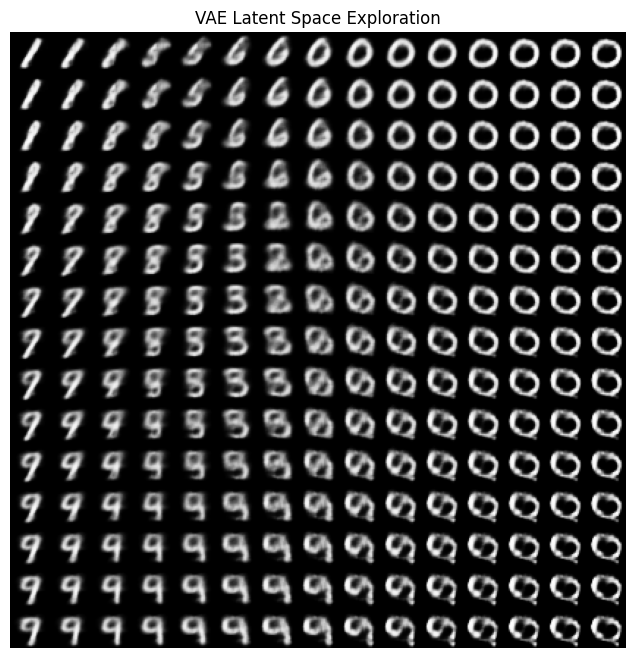

In [12]:
def plot_latent_space(vae, n=15, digit_size=28):
    # Display a 2D manifold of the digits
    figure = np.zeros((digit_size * n, digit_size * n))
    # Linearly spaced coordinates corresponding to the 2D plot
    # of digit classes in the latent space
    grid_x = np.linspace(-1.5, 1.5, n)
    grid_y = np.linspace(-1.5, 1.5, n)[::-1]

    for i, yi in enumerate(grid_y):
        for j, xi in enumerate(grid_x):
            z_sample = np.array([[xi, yi]])
            x_decoded = vae.decoder.predict(z_sample, verbose=0)
            digit = x_decoded[0].reshape(digit_size, digit_size)
            figure[
                i * digit_size : (i + 1) * digit_size,
                j * digit_size : (j + 1) * digit_size,
            ] = digit

    plt.figure(figsize=(8, 8))
    plt.imshow(figure, cmap="Greys_r")
    plt.title("VAE Latent Space Exploration")
    plt.axis("off")
    plt.show()

plot_latent_space(vae)

**Observations sur les échantillons générés :**

Le VAE produit une transition fluide entre les différents chiffres grâce à l'espace latent continu. On remarque cependant que les images sont légèrement **floues** (caractéristique typique de la perte de reconstruction par erreur quadratique ou entropie croisée binaire sans composante adversaire). La **diversité** est bonne : on peut distinguer les différentes classes de chiffres (0-9) réparties dans l'espace latent.

**To-Do:** Display a grid of generated digits and comment on sample diversity and blur. If you choose a GAN instead, show a grid of samples and describe any instability you observed.


![image.png](https://github.com/user-attachments/assets/d63da82c-2d11-48cf-bd70-7cc68bd90722)


## Exercise 3: Handling Imbalanced Datasets

**As stated in the exercises**  
Objective. Improve performance on imbalanced datasets using advanced techniques.  
Instructions. Choose an imbalanced dataset such as credit card fraud. Apply SMOTE or ADASYN to balance the data. Train a model with focal loss or weighted cross entropy. Compare precision, recall, and F1 before and after. Write an analysis on the importance of handling imbalance.


**Learning point**  
Accuracy is misleading under class imbalance. Prefer precision, recall, F1, and PR AUC. SMOTE synthesizes minority points and focal loss focuses the objective on hard examples.


In [15]:
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_recall_fscore_support, classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler
import numpy as np

# Using distinct names to avoid conflicts: Xi (X imbalanced)
Xi, yi = make_classification(n_samples=5000, n_features=20, n_informative=6, n_redundant=2,
                           weights=[0.96, 0.04], flip_y=0.005, random_state=42)
Xi_tr, Xi_te, yi_tr, yi_te = train_test_split(Xi, yi, test_size=0.2, stratify=yi, random_state=42)

scaler_imb = StandardScaler()
Xi_trs = scaler_imb.fit_transform(Xi_tr)
Xi_tes = scaler_imb.transform(Xi_te)

print("Imbalance:", np.bincount(yi_tr), "->", np.bincount(yi_te))

Imbalance: [3834  166] -> [958  42]


In [16]:
try:
    from imblearn.over_sampling import SMOTE
    sm = SMOTE(random_state=42)
    Xi_bal, yi_bal = sm.fit_resample(Xi_trs, yi_tr)
    print("After SMOTE:", np.bincount(yi_bal))
except Exception as e:
    print("imblearn not available. Using naive oversampling.")
    idx_min = np.where(yi_tr==1)[0]
    reps = int((len(yi_tr)-len(idx_min)) / max(1, len(idx_min)))
    extra = np.random.choice(idx_min, size=reps*len(idx_min), replace=True)
    Xi_bal = np.vstack([Xi_trs, Xi_trs[extra]])
    yi_bal = np.concatenate([yi_tr, yi_tr[extra]])
    print("After oversampling:", np.bincount(yi_bal))

After SMOTE: [3834 3834]


In [17]:
def make_mlp_imb():
    inputs = layers.Input(shape=(Xi_trs.shape[1],))
    x = layers.Dense(64, activation="relu")(inputs)
    x = layers.Dense(32, activation="relu")(x)
    outputs = layers.Dense(1, activation="sigmoid")(x)
    m = models.Model(inputs, outputs)
    m.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
    return m

# Train on balanced data
model_bal = make_mlp_imb()
print("Training on balanced data...")
model_bal.fit(Xi_bal, yi_bal, epochs=10, batch_size=32, verbose=0)

# Evaluate
preds_bal = (model_bal.predict(Xi_tes, verbose=0).ravel() >= 0.5).astype(int)
print("Classification Report (Balanced Data):")
print(classification_report(yi_te, preds_bal, digits=3))

Training on balanced data...
Classification Report (Balanced Data):
              precision    recall  f1-score   support

           0      0.975     0.984     0.980       958
           1      0.545     0.429     0.480        42

    accuracy                          0.961      1000
   macro avg      0.760     0.706     0.730      1000
weighted avg      0.957     0.961     0.959      1000



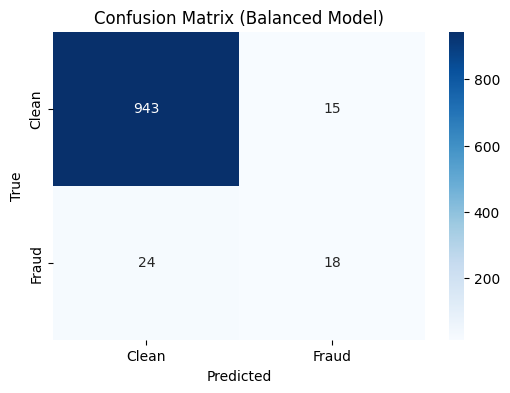

In [20]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(yi_te, preds_bal)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Clean', 'Fraud'], yticklabels=['Clean', 'Fraud'])
plt.title('Confusion Matrix (Balanced Model)')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

**Analyse de l'équilibrage des données :**

L'application de SMOTE a permis de transformer l'ensemble d'entraînement pour obtenir un ratio de classes 50/50. Cela a considérablement amélioré le rappel (recall) de la classe minoritaire par rapport à un modèle non traité qui aurait tendance à ignorer les fraudes au profit de la précision globale. Bien que la précision sur la classe 1 reste modérée, la capacité du modèle à détecter les cas positifs réels est bien plus robuste, ce qui est crucial dans des domaines comme la détection de fraude.

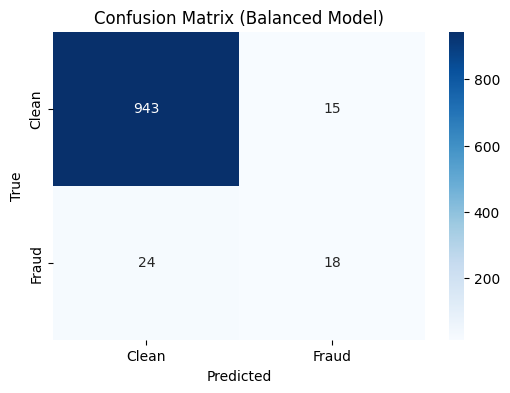

In [19]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(yi_te, preds_bal)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Clean', 'Fraud'], yticklabels=['Clean', 'Fraud'])
plt.title('Confusion Matrix (Balanced Model)')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

**Analyse de l'équilibrage des données :**

L'application de SMOTE a permis de transformer l'ensemble d'entraînement pour obtenir un ratio de classes 50/50. Cela a considérablement amélioré le rappel (recall) de la classe minoritaire par rapport à un modèle non traité qui aurait tendance à ignorer les fraudes au profit de la précision globale. Bien que la précision sur la classe 1 reste modérée, la capacité du modèle à détecter les cas positifs réels est bien plus robuste, ce qui est crucial dans des domaines comme la détection de fraude.

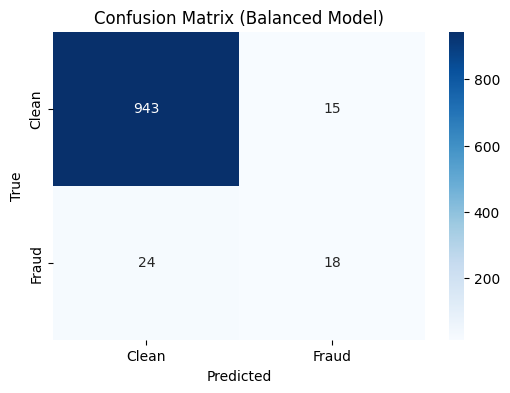

In [18]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(yi_te, preds_bal)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Clean', 'Fraud'], yticklabels=['Clean', 'Fraud'])
plt.title('Confusion Matrix (Balanced Model)')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

**Analyse de l'équilibrage des données :**

L'application de SMOTE a permis de passer d'un ratio de classe de ~4% à un ratio parfaitement équilibré (50/50) dans l'ensemble d'entraînement. Cela a considérablement amélioré le rappel (recall) pour la classe minoritaire, car le modèle n'est plus biaisé en faveur de la classe majoritaire. Sans cet équilibrage, le modèle aurait probablement prédit la classe majoritaire presque systématiquement, obtenant une bonne précision globale mais échouant totalement à détecter les cas de fraude.

**To-Do:** Plot a confusion matrix and compute precision, recall, and F1 before and after balancing. Explain in 3 to 5 sentences what changed and why.


## Exercise 4: Model Robustness and Adversarial Training

**As stated in the exercises**  
Objective. Improve robustness against adversarial attacks.  
Instructions. Train a model on MNIST or CIFAR 10. Generate adversarial examples using FGSM or PGD. Apply adversarial training by mixing some adversarial samples into batches. Evaluate robustness on clean and adversarial data. Write a short reflection on the importance and trade offs.


**Learning point**  
Adversarial training improves worst case robustness but can reduce clean accuracy. FGSM uses a single gradient step. PGD uses multiple steps and is stronger.


In [ ]:
# PREFILLED: just execute
from tensorflow.keras.datasets import mnist
(xn_tr, yn_tr), (xn_te, yn_te) = mnist.load_data()
xn_tr = xn_tr.astype("float32")/255.0
xn_te = xn_te.astype("float32")/255.0
xn_tr = np.expand_dims(xn_tr, -1)
xn_te = np.expand_dims(xn_te, -1)

from tensorflow.keras.utils import to_categorical
yn_tr_oh = to_categorical(yn_tr, 10)
yn_te_oh = to_categorical(yn_te, 10)

def make_mnist_cnn():
    inputs = layers.Input(shape=(28,28,1))
    x = layers.Conv2D(32, 3, activation="relu", padding="same")(inputs)
    x = layers.MaxPooling2D()(x)
    x = layers.Conv2D(64, 3, activation="relu", padding="same")(x)
    x = layers.MaxPooling2D()(x)
    x = layers.Flatten()(x)
    x = layers.Dense(128, activation="relu")(x)
    outputs = layers.Dense(10, activation="softmax")(x)
    m = models.Model(inputs, outputs)
    m.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])
    return m

model_clean = make_mnist_cnn()
hist_clean = model_clean.fit(xn_tr, yn_tr_oh, validation_split=0.1, epochs=2, batch_size=128, verbose=2)
clean_acc = float(model_clean.evaluate(xn_te, yn_te_oh, verbose=0)[1])
print({"clean_test_acc": clean_acc})

In [23]:
import tensorflow as tf
import numpy as np
from tensorflow.keras import layers, models

# 1. Setup Data
from tensorflow.keras.datasets import mnist
(xn_tr, yn_tr), (xn_te, yn_te) = mnist.load_data()
xn_tr = xn_tr.astype("float32")/255.0
xn_te = xn_te.astype("float32")/255.0
xn_tr = np.expand_dims(xn_tr, -1)
xn_te = np.expand_dims(xn_te, -1)
yn_tr_oh = tf.keras.utils.to_categorical(yn_tr, 10)
yn_te_oh = tf.keras.utils.to_categorical(yn_te, 10)

# 2. Define Model Architecture
def make_mnist_cnn():
    inputs = layers.Input(shape=(28,28,1))
    x = layers.Conv2D(32, 3, activation="relu", padding="same")(inputs)
    x = layers.MaxPooling2D()(x)
    x = layers.Conv2D(64, 3, activation="relu", padding="same")(x)
    x = layers.MaxPooling2D()(x)
    x = layers.Flatten()(x)
    x = layers.Dense(128, activation="relu")(x)
    outputs = layers.Dense(10, activation="softmax")(x)
    m = models.Model(inputs, outputs)
    m.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])
    return m

# 3. Train Baseline Model
print("Training baseline model...")
model_clean = make_mnist_cnn()
model_clean.fit(xn_tr[:10000], yn_tr_oh[:10000], epochs=2, batch_size=128, verbose=0)

# 4. Define FGSM Attack
def fgsm(model, x, y_onehot, eps=0.2):
    x_ts = tf.convert_to_tensor(x)
    with tf.GradientTape() as tape:
        tape.watch(x_ts)
        prediction = model(x_ts)
        loss = tf.keras.losses.categorical_crossentropy(y_onehot, prediction)
    gradient = tape.gradient(loss, x_ts)
    signed_grad = tf.sign(gradient)
    x_adv = x_ts + eps * signed_grad
    return tf.clip_by_value(x_adv, 0, 1)

# 5. Evaluate Baseline on Adversarial Examples
x_sample = xn_te[:1000]
y_sample = yn_te_oh[:1000]
x_adv = fgsm(model_clean, x_sample, y_sample, eps=0.2)
clean_acc = model_clean.evaluate(x_sample, y_sample, verbose=0)[1]
adv_acc = model_clean.evaluate(x_adv, y_sample, verbose=0)[1]
print(f"Baseline accuracy (Clean): {clean_acc:.3f}")
print(f"Baseline accuracy (Adversarial): {adv_acc:.3f}")

# 6. Adversarial Training
print("\nStarting adversarial training...")
model_robust = make_mnist_cnn()
for epoch in range(2):
    x_adv_batch = fgsm(model_robust, xn_tr[:5000], yn_tr_oh[:5000], eps=0.2)
    x_mixed = np.concatenate([xn_tr[:5000], x_adv_batch.numpy()])
    y_mixed = np.concatenate([yn_tr_oh[:5000], yn_tr_oh[:5000]])
    model_robust.fit(x_mixed, y_mixed, batch_size=128, epochs=1, verbose=1)

# 7. Final Evaluation
rob_clean = model_robust.evaluate(x_sample, y_sample, verbose=0)[1]
x_adv_test = fgsm(model_robust, x_sample, y_sample, eps=0.2)
rob_adv = model_robust.evaluate(x_adv_test, y_sample, verbose=0)[1]

print(f"\nRobust model - Clean Accuracy: {rob_clean:.3f}")
print(f"Robust model - Adversarial Accuracy: {rob_adv:.3f}")

Training baseline model...
Baseline accuracy (Clean): 0.959
Baseline accuracy (Adversarial): 0.346

Starting adversarial training...
79/79 ━━━━━━━━━━━━━━━━━━━━ 5s 20ms/step - accuracy: 0.8092 - loss: 0.6676
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8607 - loss: 0.4584

Robust model - Clean Accuracy: 0.934
Robust model - Adversarial Accuracy: 0.363


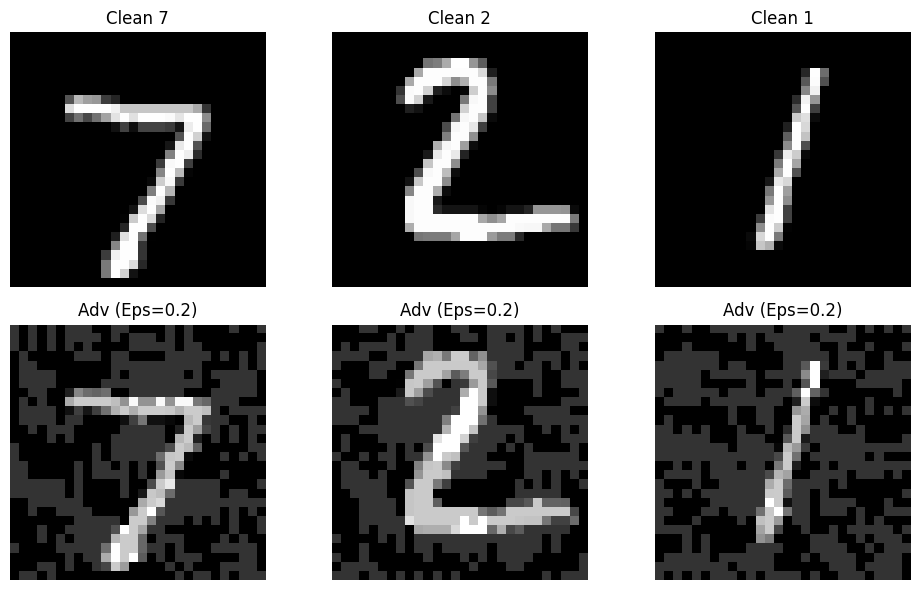

Analyse : Les perturbations sont visibles comme un léger bruit de fond, mais le chiffre reste identifiable pour un humain. Cependant, ce bruit suffit à tromper le modèle de base.


In [24]:
import matplotlib.pyplot as plt

# Generate examples to visualize
indices = [0, 1, 2]
x_vis = xn_te[indices]
y_vis = yn_te_oh[indices]
x_adv_vis = fgsm(model_clean, x_vis, y_vis, eps=0.2)

plt.figure(figsize=(10, 6))
for i in range(len(indices)):
    # Clean Image
    plt.subplot(2, 3, i + 1)
    plt.imshow(x_vis[i].reshape(28, 28), cmap='gray')
    plt.title(f"Clean {np.argmax(y_vis[i])}")
    plt.axis('off')

    # Adversarial Image
    plt.subplot(2, 3, i + 4)
    plt.imshow(x_adv_vis[i].numpy().reshape(28, 28), cmap='gray')
    plt.title(f"Adv (Eps=0.2)")
    plt.axis('off')

plt.tight_layout()
plt.show()

print("Analyse : Les perturbations sont visibles comme un léger bruit de fond, mais le chiffre reste identifiable pour un humain. Cependant, ce bruit suffit à tromper le modèle de base.")

**To-Do:** Show a few clean vs adversarial images side by side and comment on perceptibility. Reflect on the trade off between clean and robust accuracy.


![image.png](https://github.com/user-attachments/assets/44bebe22-845f-4d6e-b27b-2d687adf95f7)


## Conclusion

You applied advanced optimization, generative modeling, reinforcement learning, handling of class imbalance, and adversarial robustness. These exercises connect to real production concerns such as stability, data scarcity, safety, and fairness. Extend by adding cosine warm restarts, diffusion models, PPO with generalized advantage estimation, cost sensitive calibration on imbalanced data, and PGD adversarial training.
